# Q learning
In this lab we are going to implement what was taught in learning notes.

**Pipeline**

> Keep in mind the pipeline of Q-learning algorithims to understand the code better without being all caught up in the syntax.

1. Initialize the Q-table
2. Start the episode
3. Agent chooses an action
4. Agent performs the chosen action
5. Measure the reward
6. Update the Q-table
7. Repeat steps for the number of episodes


* This lab has been adapted by a GeeksForGeeks lab, check out for the original lab:
https://www.geeksforgeeks.org/machine-learning/q-learning-in-python/

## Learning the Code


**Define the enviornment**

This is where we initialize our table for the algorithim to save its values

*I changed the 4x4 grid to be a 5x5 grid just for more complexity

In [3]:
import numpy as np
import matplotlib.pyplot as plt

n_states = 25
n_actions = 4
goal_state = 23

Q_table = np.zeros((n_states, n_actions))

**Initialize the hyperparameters**

Straight from GeeksForGeeks:

* learning_rate (α): How much new info overrides old info.

* discount_factor (γ): How much future rewards are valued.

* exploration_prob (ε): Probability of taking a random action.

* epochs: Number of training episodes.

*I will for sure experiement with the exploration_prob and discount factor to see the differences between the Q-table

In [5]:
learning_rate = 0.8
discount_factor = 0.95
exploration_prob = 0.2
epochs = 1000

**Rules for the Agent**

This step is where we define what actions the agent can take

In [7]:
def get_next_state(state, action):
  row, col = divmod(state, 5)

  if action == 0 and col > 0:
    col -= 1
  elif action == 1 and col < 4:
    col += 1
  elif action == 2 and row > 0:
    row -= 1
  elif action == 3 and row < 4:
    row +=1

  return row * 5 + col

**The real Q-learning algorithim**

Here we finally get into actually building the algorithim where we start by randomly going to a specific state, choose which action we want to take, decide how the agent gets rewarded, and update the Q-table

In [ ]:
for epoch in range(epochs):
    # Start with any random state
    current_state = np.random.randint(0, n_states)

    while True:
        # Use Exploration vs Exploitation
        if np.random.rand() < exploration_prob:
            action = np.random.randint(0, n_actions)
        else:
            action = np.argmax(Q_table[current_state])

        next_state = get_next_state(current_state, action)

        # This is a very beginner move by the author because the agent gets almost no reward or feedback until it hits the goal
        reward = 1 if next_state == goal_state else 0

        # Update Q-Value using Bellman question
        Q_table[current_state, action] += learning_rate * (
            reward + discount_factor * np.max(Q_table[next_state]) - Q_table[current_state, action]
        )

        # Check if the next state is the goal
        if next_state == goal_state:
            break

        current_state = next_state

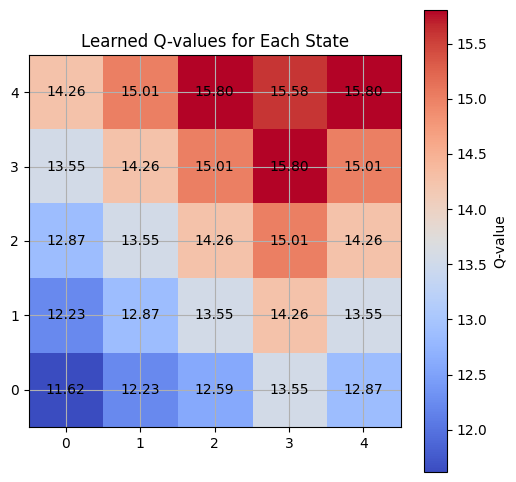

Learned Q-table:
[[ 9.60420527 11.61768472 10.73509043 10.23687157]
 [10.83041876  7.91166408 11.61417825 12.22917973]
 [11.61771022 11.27029765  9.43850544 12.59492261]
 [ 8.961702   12.07615911 10.94710716 13.55033714]
 [12.87202197  8.22814742  0.          0.        ]
 [10.08607154 11.87652176 10.39134198 12.22865715]
 [10.68190569 12.87282077 11.20799653  8.96339012]
 [12.21730795 13.55033765 11.03168111 13.53062341]
 [12.80171017 12.64785589 12.61164759 14.26351331]
 [11.97971915  9.32877545  8.374695   13.55027072]
 [10.30544479  9.61002907  8.08984955 12.87282074]
 [12.09319694  8.36022072  9.7735908  13.55032379]
 [12.54492135  0.         12.5914941  14.2635133 ]
 [13.54916168 13.53145731 13.55015221 15.01422454]
 [14.24815819 11.62253004 12.75331901 14.26351331]
 [11.38444606 13.55033765  8.92206281 13.48879007]
 [10.44950921 14.26351331 12.59570909 14.25718505]
 [12.73542932 15.01422454 13.18646039 14.69191012]
 [14.26326378 14.26330575 14.24939223 15.80444689]
 [15.01422454 

In [ ]:
q_values_grid = np.max(Q_table, axis=1).reshape((5, 5))

plt.figure(figsize=(6, 6))
plt.imshow(q_values_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Q-value')
plt.title('Learned Q-values for Each State')
plt.xticks(np.arange(5), ['0', '1', '2', '3', '4'])
plt.yticks(np.arange(5), ['0', '1', '2', '3', '4'])
plt.gca().invert_yaxis()
plt.grid(True)

for i in range(5):
    for j in range(5):
        plt.text(j, i, f'{q_values_grid[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()

print("Learned Q-table:")
print(Q_table)

### Experiment 1: Analyzing the effect of `exploration_prob` on the Q-table

To understand how the `exploration_prob` influences the learning process, we will run the Q-learning algorithm multiple times, each with a different exploration probability.

For each `exploration_prob`:
1.  Initialize a fresh Q-table.
2.  Train the agent for `epochs` episodes.
3.  Record the maximum Q-value for the goal state (state 23) in the final Q-table.

Finally, we will plot these maximum Q-values against their corresponding `exploration_prob` values.

Running Q-learning for different exploration probabilities...
  Exploration Prob: 0.05, Max Q-value at Goal: 9.30
  Exploration Prob: 0.10, Max Q-value at Goal: 9.35
  Exploration Prob: 0.15, Max Q-value at Goal: 13.77
  Exploration Prob: 0.20, Max Q-value at Goal: 14.34
  Exploration Prob: 0.25, Max Q-value at Goal: 9.33
  Exploration Prob: 0.30, Max Q-value at Goal: 8.81
  Exploration Prob: 0.35, Max Q-value at Goal: 8.94
  Exploration Prob: 0.40, Max Q-value at Goal: 8.78
  Exploration Prob: 0.45, Max Q-value at Goal: 10.71
  Exploration Prob: 0.50, Max Q-value at Goal: 13.17
  Exploration Prob: 0.55, Max Q-value at Goal: 14.14
  Exploration Prob: 0.60, Max Q-value at Goal: 9.23
  Exploration Prob: 0.65, Max Q-value at Goal: 12.28
  Exploration Prob: 0.70, Max Q-value at Goal: 10.79
  Exploration Prob: 0.75, Max Q-value at Goal: 10.36
  Exploration Prob: 0.80, Max Q-value at Goal: 12.74
  Exploration Prob: 0.85, Max Q-value at Goal: 8.43
  Exploration Prob: 0.90, Max Q-value at Goal

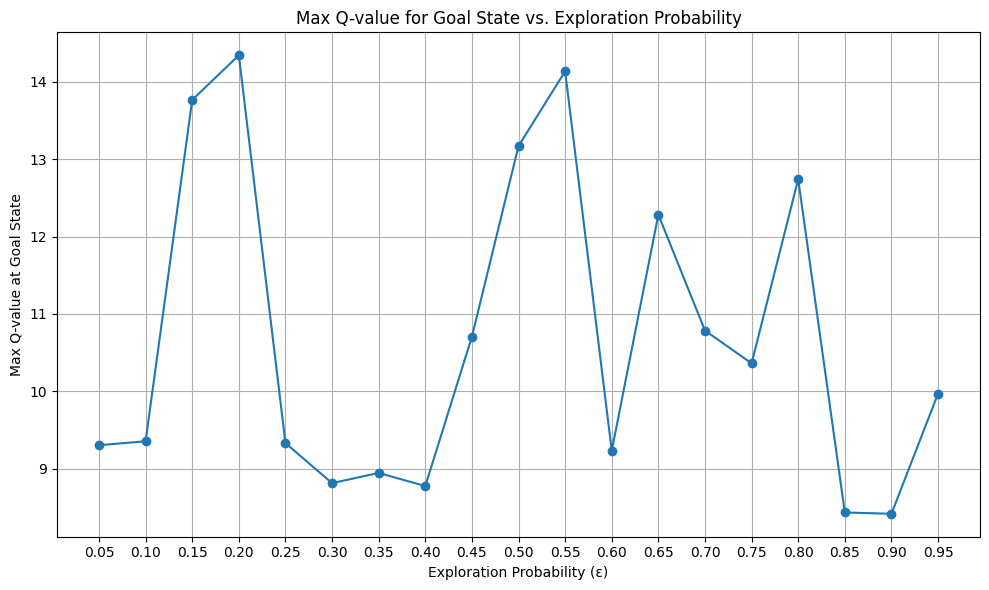

In [8]:
def train_q_learning(n_states, n_actions, goal_state, learning_rate, discount_factor, exploration_prob, epochs, get_next_state_func):
    """Trains a Q-learning agent and returns the final Q-table."""
    Q_table_experiment = np.zeros((n_states, n_actions)) # Initialize Q-table for each experiment

    for epoch in range(epochs):
        current_state = np.random.randint(0, n_states)

        while True:
            # Exploration vs Exploitation
            if np.random.rand() < exploration_prob:
                action = np.random.randint(0, n_actions)
            else:
                action = np.argmax(Q_table_experiment[current_state])

            next_state = get_next_state_func(current_state, action)

            # Reward definition
            if next_state == goal_state:
              reward = 10
            else:
              reward = -0.1

            # Update Q-Value using Bellman equation
            Q_table_experiment[current_state, action] += learning_rate * (
                reward + discount_factor * np.max(Q_table_experiment[next_state]) - Q_table_experiment[current_state, action]
            )

            # Check if the next state is the goal
            if next_state == goal_state:
                break

            current_state = next_state
    return Q_table_experiment

# Define the range of exploration probabilities to test
exploration_probs_to_test = np.arange(0.05, 1.0, 0.05) # From 0.05 to 0.95 with step 0.05
max_q_values_at_goal = []

print("Running Q-learning for different exploration probabilities...")

for prob in exploration_probs_to_test:
    # Train the Q-learning model for the current exploration probability
    final_q_table = train_q_learning(
        n_states, n_actions, goal_state, learning_rate, discount_factor,
        prob, epochs, get_next_state
    )

    # Get the maximum Q-value for the goal state (state 23)
    # The goal state Q-value should reflect how 'valuable' reaching it is.
    # np.max(Q_table[goal_state]) gets the max action value from the goal state itself.
    # If the agent stops at the goal, these might remain 0 unless the goal state is also a starting state.
    # Let's consider the maximum Q-value across all possible actions from the goal state.
    # Given how 'reward' is structured (only upon reaching the goal), the Q-values of the goal state itself might not be meaningful in the same way as other states.
    # However, for consistency with previous cells showing `np.max(Q_table, axis=1).reshape((5, 5))`, we will use the max Q-value from state 23.
    max_q_at_goal = np.max(final_q_table[goal_state])
    max_q_values_at_goal.append(max_q_at_goal)
    print(f"  Exploration Prob: {prob:.2f}, Max Q-value at Goal: {max_q_at_goal:.2f}")

# Plotting the results
fig = plt.figure(figsize=(10, 6))
plt.plot(exploration_probs_to_test, max_q_values_at_goal, marker='o', linestyle='-')
plt.title('Max Q-value for Goal State vs. Exploration Probability')
plt.xlabel('Exploration Probability (ε)')
plt.ylabel('Max Q-value at Goal State')
plt.grid(True)
plt.xticks(exploration_probs_to_test)
plt.tight_layout()
plt.show()

### Experiment 2: Variance of Max Q-value at Goal State vs. Exploration Probability

To further understand the impact of `exploration_prob`, we will repeat each `exploration_prob` 100 times and calculate the variance of the maximum Q-value achieved at the goal state. This will give us insight into the stability and consistency of the learning process for different exploration strategies.

Running Q-learning for different exploration probabilities, repeated 10 times each...
  Exploration Prob: 0.05, Variance of Max Q-value at Goal: 2.93
  Exploration Prob: 0.10, Variance of Max Q-value at Goal: 8.65
  Exploration Prob: 0.15, Variance of Max Q-value at Goal: 5.07
  Exploration Prob: 0.20, Variance of Max Q-value at Goal: 8.19
  Exploration Prob: 0.25, Variance of Max Q-value at Goal: 7.15
  Exploration Prob: 0.30, Variance of Max Q-value at Goal: 4.75
  Exploration Prob: 0.35, Variance of Max Q-value at Goal: 4.51
  Exploration Prob: 0.40, Variance of Max Q-value at Goal: 4.86
  Exploration Prob: 0.45, Variance of Max Q-value at Goal: 6.74
  Exploration Prob: 0.50, Variance of Max Q-value at Goal: 2.86
  Exploration Prob: 0.55, Variance of Max Q-value at Goal: 3.37
  Exploration Prob: 0.60, Variance of Max Q-value at Goal: 3.03
  Exploration Prob: 0.65, Variance of Max Q-value at Goal: 3.10
  Exploration Prob: 0.70, Variance of Max Q-value at Goal: 1.56
  Exploration Prob

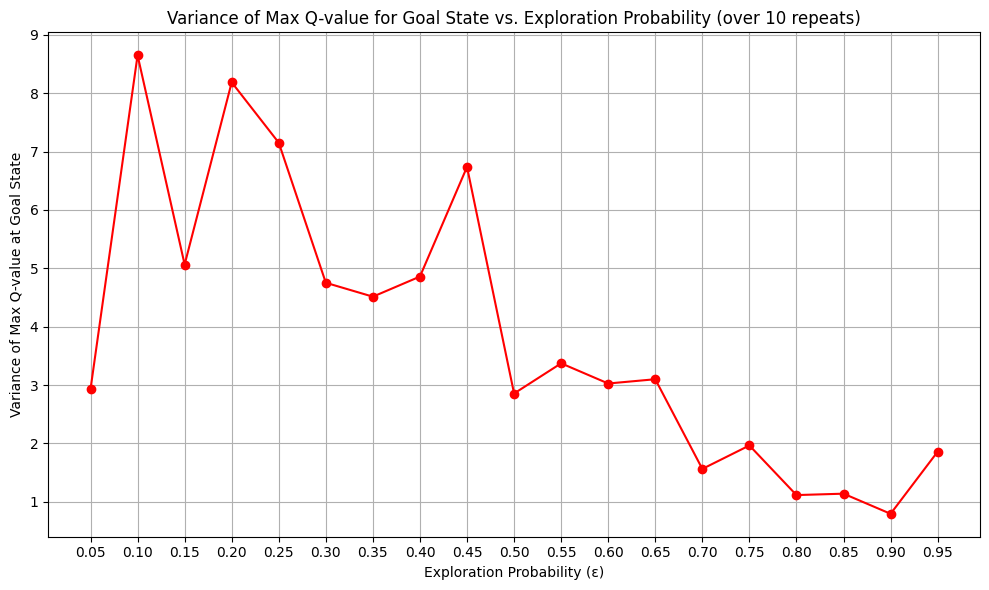

In [9]:
num_repeats = 10
variances_of_q_values_at_goal = []

print(f"Running Q-learning for different exploration probabilities, repeated {num_repeats} times each...")

for prob in exploration_probs_to_test:
    q_values_for_current_prob = []
    for _ in range(num_repeats):
        final_q_table = train_q_learning(
            n_states, n_actions, goal_state, learning_rate, discount_factor,
            prob, epochs, get_next_state
        )
        max_q_at_goal = np.max(final_q_table[goal_state])
        q_values_for_current_prob.append(max_q_at_goal)

    variance_for_prob = np.var(q_values_for_current_prob)
    variances_of_q_values_at_goal.append(variance_for_prob)
    print(f"  Exploration Prob: {prob:.2f}, Variance of Max Q-value at Goal: {variance_for_prob:.2f}")

# Plotting the results
fig = plt.figure(figsize=(10, 6))
plt.plot(exploration_probs_to_test, variances_of_q_values_at_goal, marker='o', linestyle='-', color='red')
plt.title(f'Variance of Max Q-value for Goal State vs. Exploration Probability (over {num_repeats} repeats)')
plt.xlabel('Exploration Probability (ε)')
plt.ylabel('Variance of Max Q-value at Goal State')
plt.grid(True)
plt.xticks(exploration_probs_to_test)
plt.tight_layout()
plt.show()

### Experiment 3: Success Rate of Greedy Agent After Training vs. Exploration Probability

This experiment aims to evaluate the *effectiveness* of the learned Q-table for different `exploration_prob` values. After training the Q-learning agent with a specific `exploration_prob`:
1.  We will turn off exploration (set `exploration_prob` to 0).
2.  Let the agent act greedily, always choosing the action with the highest Q-value.
3.  We'll check if the agent successfully reaches the `goal_state`.
4.  This process (training + greedy evaluation) will be repeated 20 times for each `exploration_prob` to calculate a success rate.

This will show us how well the Q-table generalizes to purely exploitative behavior after training with different levels of exploration.

Running evaluation of greedy agents for different exploration probabilities, repeated 20 times each...
  Exploration Prob: 0.05, Success Rate: 100.00%
  Exploration Prob: 0.10, Success Rate: 100.00%
  Exploration Prob: 0.15, Success Rate: 100.00%
  Exploration Prob: 0.20, Success Rate: 100.00%
  Exploration Prob: 0.25, Success Rate: 100.00%
  Exploration Prob: 0.30, Success Rate: 100.00%
  Exploration Prob: 0.35, Success Rate: 100.00%
  Exploration Prob: 0.40, Success Rate: 100.00%
  Exploration Prob: 0.45, Success Rate: 100.00%
  Exploration Prob: 0.50, Success Rate: 100.00%
  Exploration Prob: 0.55, Success Rate: 100.00%
  Exploration Prob: 0.60, Success Rate: 100.00%
  Exploration Prob: 0.65, Success Rate: 100.00%
  Exploration Prob: 0.70, Success Rate: 100.00%
  Exploration Prob: 0.75, Success Rate: 100.00%
  Exploration Prob: 0.80, Success Rate: 100.00%
  Exploration Prob: 0.85, Success Rate: 100.00%
  Exploration Prob: 0.90, Success Rate: 100.00%
  Exploration Prob: 0.95, Success

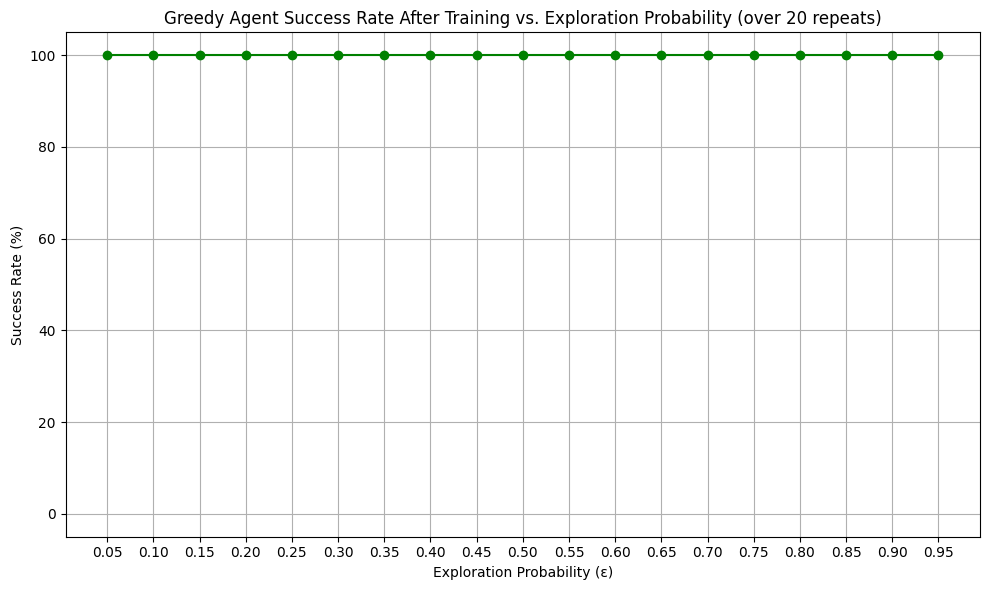

In [11]:
def evaluate_greedy_agent(q_table, n_states, goal_state, get_next_state_func, max_steps=100):
    """Evaluates if a greedy agent reaches the goal using a trained Q-table."""
    current_state = 0 # Lets start at 0 this time
    steps = 0

    while steps < max_steps:
        # Act greedily (choose action with highest Q-value)
        action = np.argmax(q_table[current_state])
        next_state = get_next_state_func(current_state, action)

        if next_state == goal_state:
            return True  # Goal reached

        current_state = next_state
        steps += 1

    return False # Max steps exceeded, goal not reached


num_eval_repeats = 20
success_rates = []

print(f"Running evaluation of greedy agents for different exploration probabilities, repeated {num_eval_repeats} times each...")

for prob in exploration_probs_to_test:
    successful_runs = 0
    for _ in range(num_eval_repeats):
        # 1. Train the Q-learning model for the current exploration probability
        final_q_table = train_q_learning(
            n_states, n_actions, goal_state, learning_rate, discount_factor,
            prob, epochs, get_next_state
        )

        # 2. Evaluate the greedy agent using the trained Q-table
        if evaluate_greedy_agent(final_q_table, n_states, goal_state, get_next_state):
            successful_runs += 1

    # Calculate success rate for the current exploration probability
    success_rate = (successful_runs / num_eval_repeats) * 100
    success_rates.append(success_rate)
    print(f"  Exploration Prob: {prob:.2f}, Success Rate: {success_rate:.2f}%")

# Plotting the results
fig = plt.figure(figsize=(10, 6))
plt.plot(exploration_probs_to_test, success_rates, marker='o', linestyle='-', color='green')
plt.title(f'Greedy Agent Success Rate After Training vs. Exploration Probability (over {num_eval_repeats} repeats)')
plt.xlabel('Exploration Probability (ε)')
plt.ylabel('Success Rate (%)')
plt.grid(True)
plt.xticks(exploration_probs_to_test)
plt.ylim(-5, 105) # Ensure y-axis covers 0-100%
plt.tight_layout()
plt.show()